# Lab 06 – Solutions (Lab Timing Tasks)

This single notebook solves the three **Lab Timing** tasks. No external datasets are needed – every dataset is **synthetically generated inside the notebook** (reproducible via fixed random seeds).

| # | Task | Technique |
|---|------|-----------|
| 1 | Computer Screen Detection in a Computer Lab | Canny + **Hough Line Transform** |
| 2 | Asset Tracking in a Computer Lab | **SIFT** + Lowe ratio test + RANSAC homography |
| 3 | Anomaly Detection in Sensor Data | **Wavelet transform** (DWT, PyWavelets) |

**Install (if needed):** `pip install opencv-python numpy matplotlib PyWavelets pandas`

In [1]:
import cv2
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt

print("OpenCV :", cv2.__version__)
print("PyWavelets :", pywt.__version__)

def show(img, title="", cmap=None, ax=None, figsize=(10, 6)):
    """Display a BGR / gray image with matplotlib."""
    if ax is None:
        plt.figure(figsize=figsize)
        ax = plt.gca()
    if img.ndim == 3:
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        ax.imshow(img, cmap=cmap or "gray")
    ax.set_title(title)
    ax.axis("off")

OpenCV : 5.0.0
PyWavelets : 1.8.0


---
# Task 1 – Computer Screen Detection in a Computer Lab (Hough Line Transform)

**Goal:** find the boundaries of computer screens in a lab with rows of computers, decide whether each is **ON/OFF**, and flag **missing screens**.

**Pipeline**
1. Generate a synthetic lab image (rows of desks, monitors; some OFF, some missing).
2. Grayscale → Gaussian blur → **Canny** edges.
3. **Probabilistic Hough Line Transform** (`cv2.HoughLinesP`) to find straight edge segments.
4. Draw the detected lines on a blank mask; the *enclosed* regions between lines are the screen candidates.
5. Filter candidates by area, aspect-ratio and "rectangularity" → screen boundaries.
6. Brightness of each screen → **ON / OFF**.
7. Cluster screens into rows / columns, compare with the expected grid → **MISSING** screens.

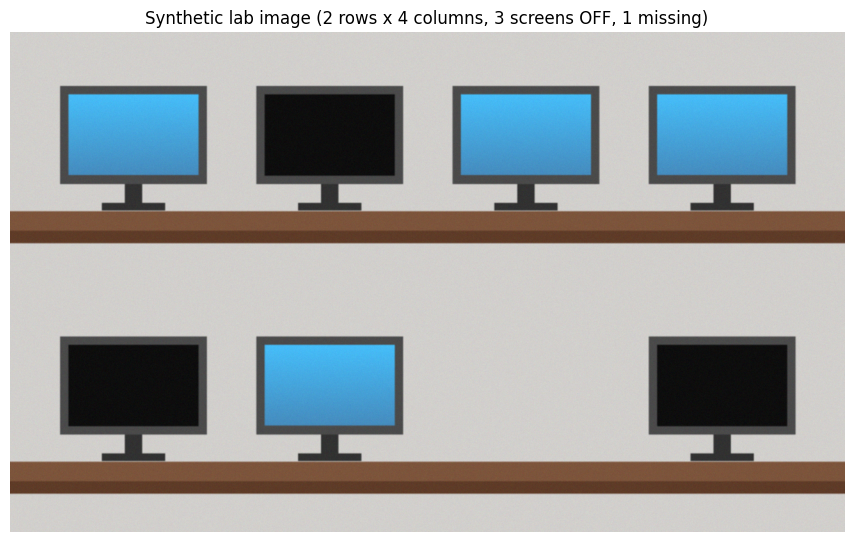

In [3]:
def make_lab_image(n_rows=2, n_cols=4, off=((0, 1), (1, 0), (1, 3)), missing=((1, 2),),
                   W=1200, H=720, seed=7):
    """Synthetic lab: n_rows x n_cols of monitors on desks.
    off     : (row, col) monitors that are switched OFF (dark screen)
    missing : (row, col) positions where no monitor is present"""
    rng = np.random.default_rng(seed)
    img = np.full((H, W, 3), (205, 208, 210), np.uint8)             # wall
    mw, mh = 210, 140                                               # monitor outer size
    gap_x = (W - n_cols * mw) // (n_cols + 1)
    row_h = H // n_rows
    truth = []
    for r in range(n_rows):
        desk_y = r * row_h + int(row_h * 0.72)
        cv2.rectangle(img, (0, desk_y), (W, desk_y + 28), (60, 85, 125), -1)     # desk top
        cv2.rectangle(img, (0, desk_y + 28), (W, desk_y + 45), (40, 60, 95), -1) # desk edge
        for c in range(n_cols):
            x = gap_x + c * (mw + gap_x)
            y = desk_y - mh - 40
            if (r, c) in missing:
                continue
            # stand + base
            cv2.rectangle(img, (x + mw//2 - 12, y + mh), (x + mw//2 + 12, y + mh + 28), (50, 50, 50), -1)
            cv2.rectangle(img, (x + mw//2 - 45, y + mh + 28), (x + mw//2 + 45, y + mh + 38), (50, 50, 50), -1)
            # bezel
            cv2.rectangle(img, (x, y), (x + mw, y + mh), (75, 75, 75), -1)
            # screen
            sx0, sy0, sx1, sy1 = x + 12, y + 12, x + mw - 12, y + mh - 12
            if (r, c) in off:
                cv2.rectangle(img, (sx0, sy0), (sx1, sy1), (14, 14, 14), -1)
                state = "OFF"
            else:
                for yy in range(sy0, sy1):                          # soft blue gradient
                    t = (yy - sy0) / (sy1 - sy0)
                    cv2.line(img, (sx0, yy), (sx1, yy), (250 - 60*t, 190 - 50*t, 70), 1)
                state = "ON"
            truth.append(dict(row=r, col=c, state=state))
    img = cv2.GaussianBlur(img, (3, 3), 0)
    noise = rng.normal(0, 3, img.shape)
    return np.clip(img + noise, 0, 255).astype(np.uint8), truth

lab_img, truth = make_lab_image()
show(lab_img, "Synthetic lab image (2 rows x 4 columns, 3 screens OFF, 1 missing)", figsize=(11, 6.5))

Hough line segments found: 125
Axis-aligned lines kept   : 125


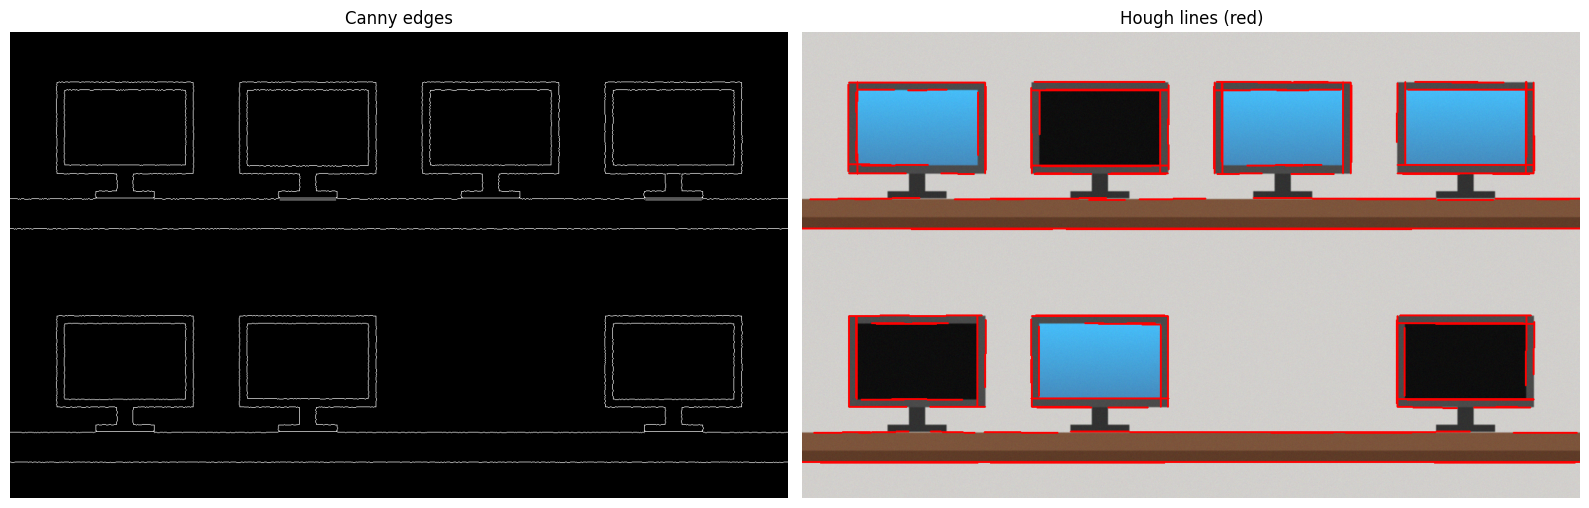

In [5]:
import cv2
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt

# ---- Steps 2-3: edges + Hough lines ----
gray  = cv2.cvtColor(lab_img, cv2.COLOR_BGR2GRAY)
blur  = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blur, 30, 90)

lines_raw = cv2.HoughLinesP(edges,
                        rho=1, theta=np.pi/180,
                        threshold=40,          # votes needed in accumulator
                        minLineLength=50,      # ignore tiny segments
                        maxLineGap=15)          # bridge small gaps

# Fix: Use reshape(-1, 4) to handle both (N, 1, 4) and (N, 4) outputs from HoughLinesP
if lines_raw is not None:
    lines = lines_raw.reshape(-1, 4)
else:
    lines = np.empty((0, 4), int)

print("Hough line segments found:", len(lines))

# keep only (almost) horizontal / vertical lines - screens are rectangles
def is_axis_aligned(l, tol_deg=5):
    x1, y1, x2, y2 = l
    ang = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
    return min(ang, abs(ang - 90), abs(ang - 180)) < tol_deg
lines = np.asarray(lines).reshape(-1, 4) if lines is not None else np.empty((0, 4), int)
print("Axis-aligned lines kept   :", len(lines))

line_vis = lab_img.copy()
for x1, y1, x2, y2 in lines:
    cv2.line(line_vis, (x1, y1), (x2, y2), (0, 0, 255), 2)

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
show(edges, "Canny edges", ax=ax[0])
show(line_vis, "Hough lines (red)", ax=ax[1])
plt.tight_layout(); plt.show()

In [6]:
# ---- Step 4-5: enclosed regions between Hough lines -> screen rectangles ----
def extend(l, d=50):
    """Extend a segment by d px at both ends so neighbouring lines meet at the corners."""
    x1, y1, x2, y2 = map(float, l)
    L = np.hypot(x2 - x1, y2 - y1); ux, uy = (x2 - x1) / L, (y2 - y1) / L
    return (int(x1 - ux*d), int(y1 - uy*d)), (int(x2 + ux*d), int(y2 + uy*d))

mask = np.zeros(gray.shape, np.uint8)
for l in lines:
    p1, p2 = extend(l)
    cv2.line(mask, p1, p2, 255, 3)

n, labels, stats, cents = cv2.connectedComponentsWithStats(255 - mask, connectivity=4)
H, W = gray.shape
screens = []
for i in range(1, n):
    x, y, w, h, area = stats[i]
    extent = area / float(w * h)                  # 1.0 => perfectly rectangular filled region
    aspect = w / float(h)
    touches_border = x <= 1 or y <= 1 or x + w >= W - 1 or y + h >= H - 1
    if (4000 < area < 60000 and extent > 0.85 and 1.2 < aspect < 2.2 and not touches_border):
        screens.append((x, y, w, h))
screens = sorted(screens, key=lambda b: (b[1] // 100, b[0]))
print("Screens detected:", len(screens))

Screens detected: 7


Inferred grid: 2 rows x 4 columns


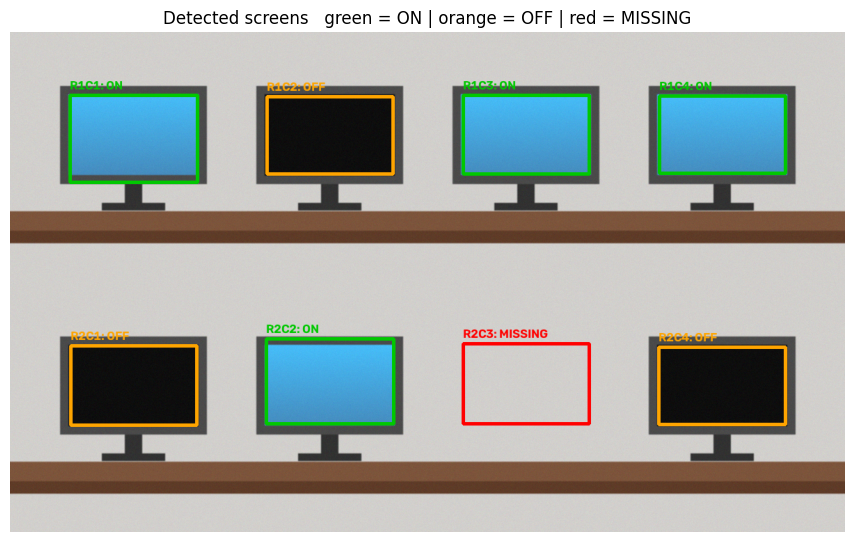

,Row,Col,Status,Brightness
0,1,1,ON,139.9
1,1,2,OFF,13.5
2,1,3,ON,142.7
3,1,4,ON,142.7
4,2,1,OFF,13.5
5,2,2,ON,143.6
6,2,3,MISSING,NaN
7,2,4,OFF,13.5


Status
ON         4
OFF        3
MISSING    1


In [7]:
# ---- Step 6: ON / OFF status ----
def screen_status(gray, box, thr=70):
    x, y, w, h = box
    m = 8                                            # shrink to avoid border pixels
    roi = gray[y+m:y+h-m, x+m:x+w-m]
    mean_val = roi.mean()
    return ("ON" if mean_val > thr else "OFF"), mean_val

# ---- Step 7: group into rows / columns and find missing screens ----
def cluster_1d(values, tol):
    order = np.argsort(values); groups = []; cur = [order[0]]
    for a, b in zip(order[:-1], order[1:]):
        if values[b] - values[a] > tol: groups.append(cur); cur = [b]
        else: cur.append(b)
    groups.append(cur)
    lab = np.zeros(len(values), int)
    for gi, g in enumerate(groups): lab[g] = gi
    centers = [np.mean([values[i] for i in g]) for g in groups]
    return lab, centers

cx = np.array([x + w/2 for x, y, w, h in screens]); cy = np.array([y + h/2 for x, y, w, h in screens])
row_lab, row_c = cluster_1d(cy, tol=60)
col_lab, col_c = cluster_1d(cx, tol=60)
n_rows, n_cols = len(row_c), len(col_c)
print(f"Inferred grid: {n_rows} rows x {n_cols} columns")

grid = {}
for k, box in enumerate(screens):
    st, mv = screen_status(gray, box)
    grid[(row_lab[k], col_lab[k])] = (box, st, mv)

result = lab_img.copy()
report = []
mw_avg = int(np.mean([b[2] for b in screens])); mh_avg = int(np.mean([b[3] for b in screens]))
for r in range(n_rows):
    for c in range(n_cols):
        if (r, c) in grid:
            (x, y, w, h), st, mv = grid[(r, c)]
            col = (0, 200, 0) if st == "ON" else (0, 165, 255)
            cv2.rectangle(result, (x, y), (x + w, y + h), col, 3)
            cv2.putText(result, f"R{r+1}C{c+1}: {st}", (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
            report.append(dict(Row=r+1, Col=c+1, Status=st, Brightness=round(mv, 1)))
        else:                                              # expected but absent -> anomaly
            x = int(col_c[c] - mw_avg/2); y = int(row_c[r] - mh_avg/2)
            cv2.rectangle(result, (x, y), (x + mw_avg, y + mh_avg), (0, 0, 255), 3, cv2.LINE_8)
            cv2.putText(result, f"R{r+1}C{c+1}: MISSING", (x, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)
            report.append(dict(Row=r+1, Col=c+1, Status="MISSING", Brightness=np.nan))

show(result, "Detected screens   green = ON | orange = OFF | red = MISSING", figsize=(11, 6.5))
plt.show()
df_screens = pd.DataFrame(report)
display(df_screens)
print(df_screens.Status.value_counts().to_string())

In [8]:
# ---- Sanity check against the ground truth used to generate the image ----
gt = pd.DataFrame(truth).rename(columns={"row": "Row", "col": "Col", "state": "TrueState"})
gt["Row"] += 1; gt["Col"] += 1
chk = df_screens.merge(gt, on=["Row", "Col"], how="left").fillna({"TrueState": "MISSING"})
print("Detection correct for all cells:", (chk.Status == chk.TrueState).all())

Detection correct for all cells: True


---
# Task 2 – Asset Tracking in a Computer Lab Using SIFT

**Goal:** automatically recognise individual computer components (**monitor, keyboard, CPU tower**) in a lab scene and build an inventory.

**Pipeline**
1. Build *reference templates* for each asset type (textured so SIFT has distinctive features).
2. Build a *lab scene* in which several instances appear at different **scales** and **rotations**.
3. Extract SIFT keypoints + descriptors for templates and scene.
4. Match with `BFMatcher.knnMatch` + **Lowe's ratio test**.
5. Estimate a **homography with RANSAC** → bounding polygon of the object.
6. Repeat per template (removing keypoints of already-found instances) to find **multiple instances**.
7. Print the inventory table with an asset ID per detected item.

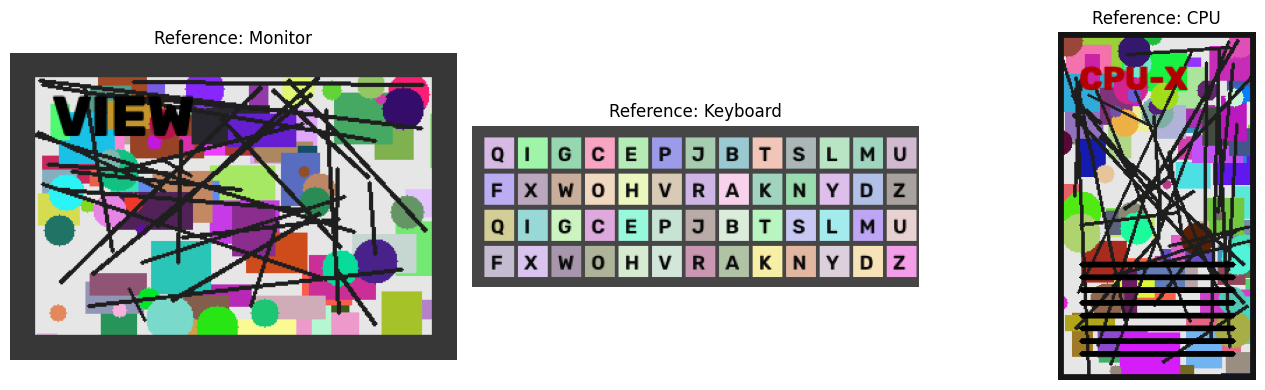

In [9]:
# ---------- 1. reference templates (synthetic but richly textured) ----------
def _texture(w, h, rng, n=60):
    """Random coloured blocks / circles / lines -> lots of corners for SIFT."""
    t = np.full((h, w, 3), 230, np.uint8)
    for _ in range(n):
        p1 = (int(rng.integers(0, w)), int(rng.integers(0, h)))
        p2 = (min(w-1, p1[0] + int(rng.integers(10, 60))), min(h-1, p1[1] + int(rng.integers(10, 40))))
        cv2.rectangle(t, p1, p2, tuple(int(v) for v in rng.integers(20, 255, 3)), -1)
    for _ in range(n // 2):
        cv2.circle(t, (int(rng.integers(0, w)), int(rng.integers(0, h))), int(rng.integers(4, 18)),
                   tuple(int(v) for v in rng.integers(0, 255, 3)), -1)
    for _ in range(n // 2):
        cv2.line(t, (int(rng.integers(0, w)), int(rng.integers(0, h))),
                 (int(rng.integers(0, w)), int(rng.integers(0, h))), (30, 30, 30), 2)
    return t

def make_template(kind):
    if kind == "Monitor":
        rng = np.random.default_rng(11); w, h = 320, 220
        img = np.full((h, w, 3), 55, np.uint8)
        img[18:h-18, 18:w-18] = _texture(w-36, h-36, rng)
        cv2.putText(img, "VIEW", (30, 60), cv2.FONT_HERSHEY_DUPLEX, 1.4, (0, 0, 0), 3)
    elif kind == "Keyboard":
        rng = np.random.default_rng(22); w, h = 360, 130
        img = np.full((h, w, 3), (70, 70, 70), np.uint8)
        letters = "QWERTYUIOPASDFGHJKLZXCVBNM"
        k = 0
        for r in range(4):
            for c in range(13):
                x, y = 10 + c * 27, 10 + r * 29
                col = tuple(int(v) for v in rng.integers(150, 250, 3))
                cv2.rectangle(img, (x, y), (x + 23, y + 24), col, -1)
                cv2.putText(img, letters[k % 26], (x + 5, y + 19), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (10, 10, 10), 2)
                k += 7
    else:  # "CPU"
        rng = np.random.default_rng(33); w, h = 170, 300
        img = _texture(w, h, rng, n=70)
        cv2.rectangle(img, (0, 0), (w-1, h-1), (20, 20, 20), 8)
        for i in range(8):
            cv2.line(img, (20, 200 + i*11), (w-20, 200 + i*11), (0, 0, 0), 3)
        cv2.putText(img, "CPU-X", (18, 50), cv2.FONT_HERSHEY_DUPLEX, 1.0, (0, 0, 180), 2)
    return img

templates = {k: make_template(k) for k in ["Monitor", "Keyboard", "CPU"]}
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, (k, im) in zip(ax, templates.items()):
    show(im, f"Reference: {k}", ax=a)
plt.tight_layout(); plt.show()

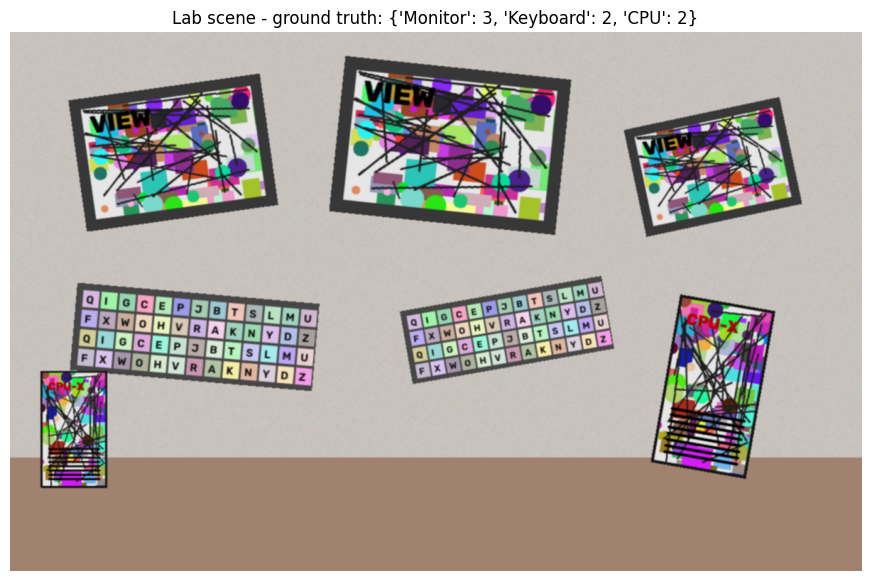

In [10]:
# ---------- 2. lab scene with transformed instances ----------
def place(scene, tmpl, cx, cy, scale, angle):
    h, w = tmpl.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
    M[:, 2] += (cx - w/2, cy - h/2)
    Hs, Ws = scene.shape[:2]
    warped = cv2.warpAffine(tmpl, M, (Ws, Hs), flags=cv2.INTER_LINEAR)
    m = cv2.warpAffine(np.full((h, w), 255, np.uint8), M, (Ws, Hs))
    scene[m > 128] = warped[m > 128]
    return scene

rng = np.random.default_rng(5)
scene = np.full((760, 1200, 3), (190, 195, 200), np.uint8)
scene = np.clip(scene + rng.normal(0, 6, scene.shape), 0, 255).astype(np.uint8)
cv2.rectangle(scene, (0, 600), (1200, 760), (110, 130, 160), -1)            # desk area

layout = [("Monitor",  230, 170, 0.85,   8), ("Monitor",  620, 160, 1.00, -6),
          ("Monitor",  990, 190, 0.70,  12), ("Keyboard", 260, 430, 0.95,  -5),
          ("Keyboard", 700, 420, 0.80,  10), ("CPU",      990, 500, 0.80,  -10),
          ("CPU",      90,  560, 0.55,   0)]
for name, cx, cy, s, a in layout:
    scene = place(scene, templates[name], cx, cy, s, a)
scene = cv2.GaussianBlur(scene, (3, 3), 0)
show(scene, f"Lab scene - ground truth: {pd.Series([l[0] for l in layout]).value_counts().to_dict()}", figsize=(12, 7))

Scene keypoints: 5966


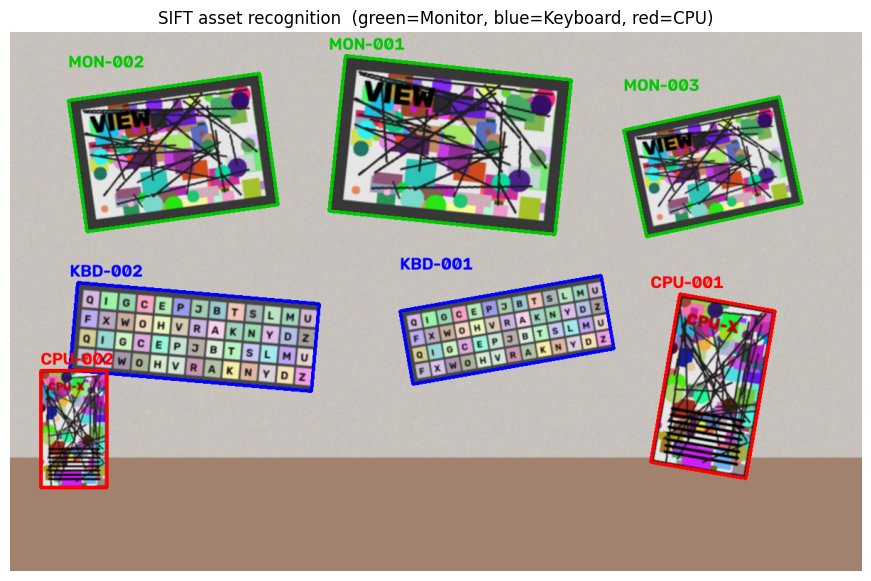

In [11]:
# ---------- 3-6. SIFT + ratio test + RANSAC (multi-instance) ----------
sift = cv2.SIFT_create(nfeatures=0, contrastThreshold=0.03)
bf   = cv2.BFMatcher(cv2.NORM_L2)

gray_scene = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
kp_s, des_s = sift.detectAndCompute(gray_scene, None)
pts_s = np.float32([k.pt for k in kp_s])
print("Scene keypoints:", len(kp_s))

RATIO, MIN_INLIERS, MAX_INST = 0.75, 12, 6

def find_instances(name, tmpl):
    g = cv2.cvtColor(tmpl, cv2.COLOR_BGR2GRAY)
    kp_t, des_t = sift.detectAndCompute(g, None)
    pts_t = np.float32([k.pt for k in kp_t])
    h, w = g.shape
    corners = np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2)
    available = np.ones(len(kp_s), bool)          # scene keypoints not yet explained
    found = []
    for _ in range(MAX_INST):
        idx = np.where(available)[0]
        if len(idx) < 2: break
        knn = bf.knnMatch(des_t, des_s[idx], k=2)
        good = [(m.queryIdx, idx[m.trainIdx]) for m, n in (p for p in knn if len(p) == 2)
                if m.distance < RATIO * n.distance]
        if len(good) < MIN_INLIERS: break
        src = pts_t[[q for q, t in good]].reshape(-1, 1, 2)
        dst = pts_s[[t for q, t in good]].reshape(-1, 1, 2)
        Hm, inl = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        if Hm is None or inl.sum() < MIN_INLIERS: break
        poly = cv2.perspectiveTransform(corners, Hm).reshape(-1, 2)
        # geometric sanity: convex & sensible area
        if not cv2.isContourConvex(poly.astype(np.float32)) or cv2.contourArea(poly.astype(np.float32)) < 2000:
            for q, t in [good[i] for i in np.where(inl.ravel() == 1)[0]]: available[t] = False
            continue
        found.append(dict(poly=poly, inliers=int(inl.sum()), matches=good, mask=inl.ravel()))
        # remove every scene keypoint that lies inside this instance
        inside = np.array([cv2.pointPolygonTest(poly.astype(np.float32), (float(x), float(y)), False) >= 0
                           for x, y in pts_s])
        available &= ~inside
    return found, kp_t

colors = {"Monitor": (0, 200, 0), "Keyboard": (255, 0, 0), "CPU": (0, 0, 255)}
prefix = {"Monitor": "MON", "Keyboard": "KBD", "CPU": "CPU"}
annotated = scene.copy(); inventory = []; store = {}
for name, tmpl in templates.items():
    found, kp_t = find_instances(name, tmpl)
    store[name] = (found, kp_t)
    for i, f in enumerate(found, 1):
        asset_id = f"{prefix[name]}-{i:03d}"
        cv2.polylines(annotated, [f["poly"].astype(np.int32)], True, colors[name], 4)
        x, y = f["poly"].min(axis=0).astype(int)
        cv2.putText(annotated, asset_id, (x, max(20, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.8, colors[name], 2)
        cx, cy = f["poly"].mean(axis=0).astype(int)
        inventory.append(dict(AssetID=asset_id, Type=name, Inliers=f["inliers"], Center=(int(cx), int(cy))))

show(annotated, "SIFT asset recognition  (green=Monitor, blue=Keyboard, red=CPU)", figsize=(12, 7))
plt.show()

,AssetID,Type,Inliers,Center
0,MON-001,Monitor,156,"(620, 159)"
1,MON-002,Monitor,129,"(229, 170)"
2,MON-003,Monitor,210,"(990, 190)"
3,KBD-001,Keyboard,97,"(700, 420)"
4,KBD-002,Keyboard,198,"(259, 430)"
5,CPU-001,CPU,228,"(990, 499)"
6,CPU-002,CPU,177,"(90, 560)"



INVENTORY SUMMARY
Type
Monitor     3
Keyboard    2
CPU         2

Ground truth      : {'Monitor': 3, 'Keyboard': 2, 'CPU': 2}
Detected == truth : True


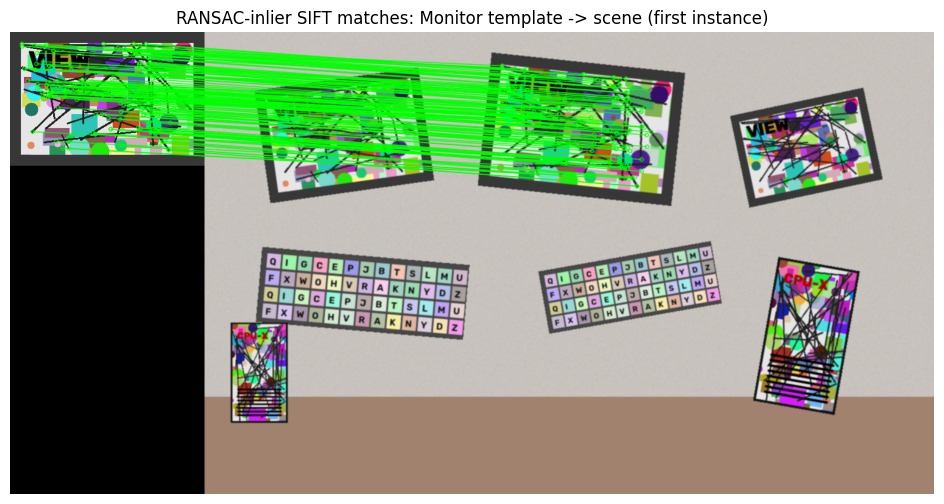

In [12]:
# ---------- 7. inventory ----------
inv = pd.DataFrame(inventory)
display(inv)
print("\nINVENTORY SUMMARY")
print(inv.Type.value_counts().to_string())
truth_counts = pd.Series([l[0] for l in layout]).value_counts()
print("\nGround truth      :", truth_counts.to_dict())
print("Detected == truth :", inv.Type.value_counts().to_dict() == truth_counts.to_dict())

# visualise the SIFT matches for one instance (first monitor)
f = store["Monitor"][0][0]; kp_t = store["Monitor"][1]
good_dm = [cv2.DMatch(q, t, 0) for (q, t), ok in zip(f["matches"], f["mask"]) if ok]
vis = cv2.drawMatches(templates["Monitor"], kp_t, scene, kp_s, good_dm, None,
                      matchColor=(0, 255, 0), flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
show(vis, "RANSAC-inlier SIFT matches: Monitor template -> scene (first instance)", figsize=(14, 6))

---
# Task 3 – Anomaly Detection in Sensor Data Using Wavelet Transformation

**Goal:** monitor sensor data from an industrial machine and detect anomalies in an automated way.

**Idea**
* A healthy sensor = smooth underlying trend + small noise.
* Apply a multilevel **Discrete Wavelet Transform** (`db4`, 4 levels). The *approximation* coefficients hold the slow trend, the *detail* coefficients hold fast variation (noise **and** sudden spikes).
* **Denoised signal** = reconstruction after removing the detail coefficients.
* **Residual** = raw data − denoised signal. Anomalies are residual samples that exceed a robust threshold (`k` × MAD-based σ).
* As a 2nd view, spikes are also visible directly as unusually large **level-1 detail coefficients**.

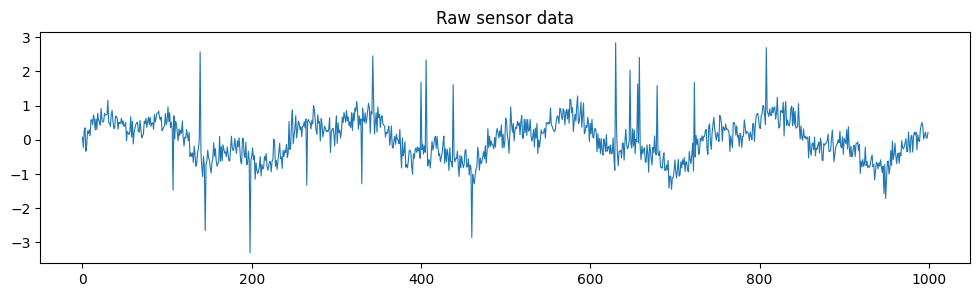

Injected anomalies: 18


In [13]:
# ---------- sample sensor dataset ----------
rng = np.random.default_rng(42)
N = 1000
t = np.arange(N)
trend = 0.6*np.sin(2*np.pi*t/250) + 0.3*np.sin(2*np.pi*t/80)          # normal machine behaviour
signal = trend + rng.normal(0, 0.25, N)                                 # + sensor noise

true_anom = np.sort(rng.choice(np.arange(20, N-20), 18, replace=False)) # injected faults (spikes / dips)
signal[true_anom] += rng.choice([-1, 1], len(true_anom)) * rng.uniform(1.6, 2.8, len(true_anom))

plt.figure(figsize=(12, 3)); plt.plot(signal, lw=0.8); plt.title("Raw sensor data"); plt.show()
print("Injected anomalies:", len(true_anom))

In [14]:
# ---------- wavelet decomposition & denoising ----------
WAVELET, LEVEL = "db4", 4
coeffs = pywt.wavedec(signal, WAVELET, level=LEVEL)        # [cA4, cD4, cD3, cD2, cD1]

den_coeffs = [coeffs[0]] + [np.zeros_like(c) for c in coeffs[1:]]   # keep only the trend (approximation)
denoised = pywt.waverec(den_coeffs, WAVELET)[:N]

residual = signal - denoised

# ---------- robust anomaly threshold on residuals ----------
K = 3.5
sigma = np.median(np.abs(residual - np.median(residual))) / 0.6745     # MAD estimate of noise std
thr = K * sigma
anom_idx = np.where(np.abs(residual) > thr)[0]
print(f"sigma(residual) = {sigma:.3f}   threshold = ±{thr:.3f}")
print("Detected anomalies:", len(anom_idx))

sigma(residual) = 0.251   threshold = ±0.879
Detected anomalies: 19


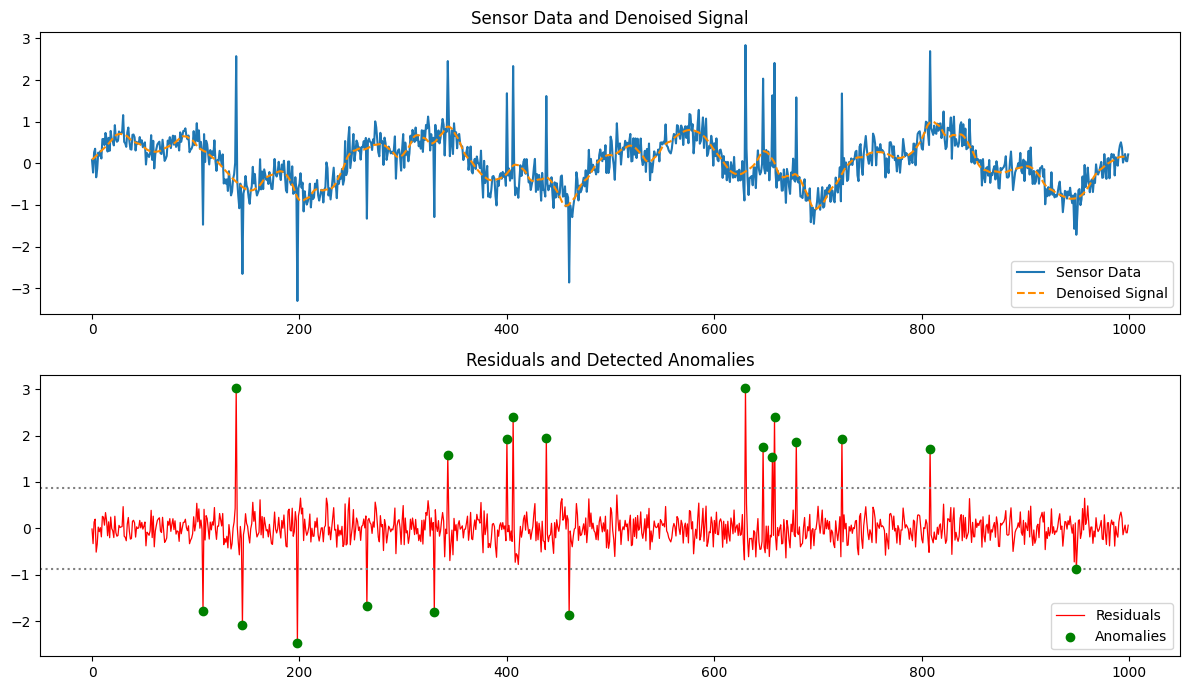

In [15]:
# ---------- plots (same layout as the expected output) ----------
fig, ax = plt.subplots(2, 1, figsize=(12, 7))
ax[0].plot(signal, label="Sensor Data")
ax[0].plot(denoised, "--", label="Denoised Signal", color="darkorange", lw=1.5)
ax[0].set_title("Sensor Data and Denoised Signal"); ax[0].legend(loc="lower right")

ax[1].plot(residual, color="red", label="Residuals", lw=0.9)
ax[1].scatter(anom_idx, residual[anom_idx], color="green", zorder=3, label="Anomalies")
ax[1].axhline(thr, ls=":", color="gray"); ax[1].axhline(-thr, ls=":", color="gray")
ax[1].set_title("Residuals and Detected Anomalies"); ax[1].legend(loc="lower right")
plt.tight_layout(); plt.show()

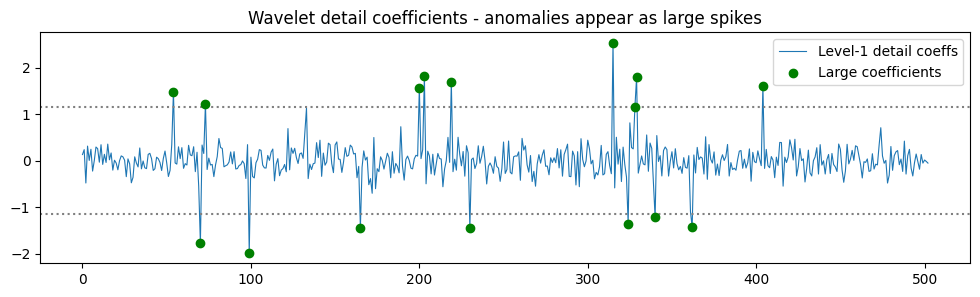

,TrueAnomalies,Detected,Recall,Precision,FalseAlarms
Residual-threshold method,18.0,19.0,1.000,0.947,1.0
Detail-coefficient method,18.0,32.0,0.889,1.000,0.0


In [16]:
# ---------- 2nd view: wavelet detail coefficients (level 1) ----------
d1 = coeffs[-1]
s1 = np.median(np.abs(d1)) / 0.6745
d_idx = np.where(np.abs(d1) > 4.5 * s1)[0]
anom_wavelet = np.unique(np.clip(np.concatenate([2*d_idx, 2*d_idx+1]), 0, N-1))   # map coeff -> samples

plt.figure(figsize=(12, 3))
plt.plot(d1, lw=0.8, label="Level-1 detail coeffs")
plt.scatter(d_idx, d1[d_idx], color="green", zorder=3, label="Large coefficients")
plt.axhline(4.5*s1, ls=":", c="gray"); plt.axhline(-4.5*s1, ls=":", c="gray")
plt.title("Wavelet detail coefficients - anomalies appear as large spikes"); plt.legend(); plt.show()

# ---------- evaluation against injected anomalies (±2 sample tolerance) ----------
def evaluate(detected, truth, tol=2):
    tp = sum(any(abs(d - t) <= tol for d in detected) for t in truth)
    fp = sum(not any(abs(d - t) <= tol for t in truth) for d in detected)
    prec = (len(detected) - fp) / max(1, len(detected))
    rec = tp / len(truth)
    return dict(TrueAnomalies=len(truth), Detected=len(detected), Recall=round(rec, 3), Precision=round(prec, 3), FalseAlarms=fp)

res = pd.DataFrame({"Residual-threshold method": evaluate(anom_idx, true_anom),
                    "Detail-coefficient method": evaluate(anom_wavelet, true_anom)}).T
display(res)

---
## Summary

| Task | Key steps | Result |
|------|-----------|--------|
| 1. Screen detection | Canny → `HoughLinesP` → keep horizontal/vertical lines → enclosed rectangles → brightness test → grid comparison | Each screen boxed, labelled **ON / OFF**, empty slot flagged **MISSING** |
| 2. Asset tracking | SIFT features → ratio test → RANSAC homography → repeat per template | Each monitor/keyboard/CPU found at different scale & rotation, with asset IDs and an inventory table |
| 3. Wavelet anomalies | `db4` DWT (4 levels) → drop details → residual → MAD threshold | Denoised signal + residual plot with green anomaly markers, plus evaluation |

**Using real data:** replace `lab_img` (Task 1) with `cv2.imread("lab.jpg")`, replace `templates`/`scene` (Task 2) with your own cropped reference images and lab photo, and replace `signal` (Task 3) with your sensor array. Tune Canny/Hough thresholds, `RATIO`, `MIN_INLIERS` and `K` for your data.